# `v71_fig1b_p38`

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import EVALUATE_ALL_CSVS

model = "EGFR_MAPK__logobs"
data = "dream_cytof"
filename = "evaluate_all_figure1b"

df = pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename), index_col=0)

In [19]:
val_df = df[(df.dataset == "val") & (df.ref == "DMM")]
val_df.features.fillna("None", inplace=True)

# Exclude multimodal best_RFE
val_df = val_df[val_df.features != "best_RFE_10_permute"]

In [20]:
val_df.groupby(["context", "features", "multiheaded", "n_hidden", "depth", "dropout_rate", "l1reg_inflater_output", "l2reg_inflater_output", "recon_loss"]).rmse.mean()

context          features           multiheaded  n_hidden  depth  dropout_rate  l1reg_inflater_output  l2reg_inflater_output  recon_loss
cytof_init       RFE_15_permute     False        2.0       0.0    0.0           0.0100                 0.0                    0.0001        0.608058
                                                                  0.1           0.0100                 0.0                    0.0001        0.584546
                                                                  0.2           0.0000                 0.0                    0.0001        0.614198
                                                                                0.0001                 0.0                    0.0001        0.610579
                                                                                0.0010                 0.0                    0.0001        0.596449
                                                                                                                      

# n_hidden (fixed depth=0)

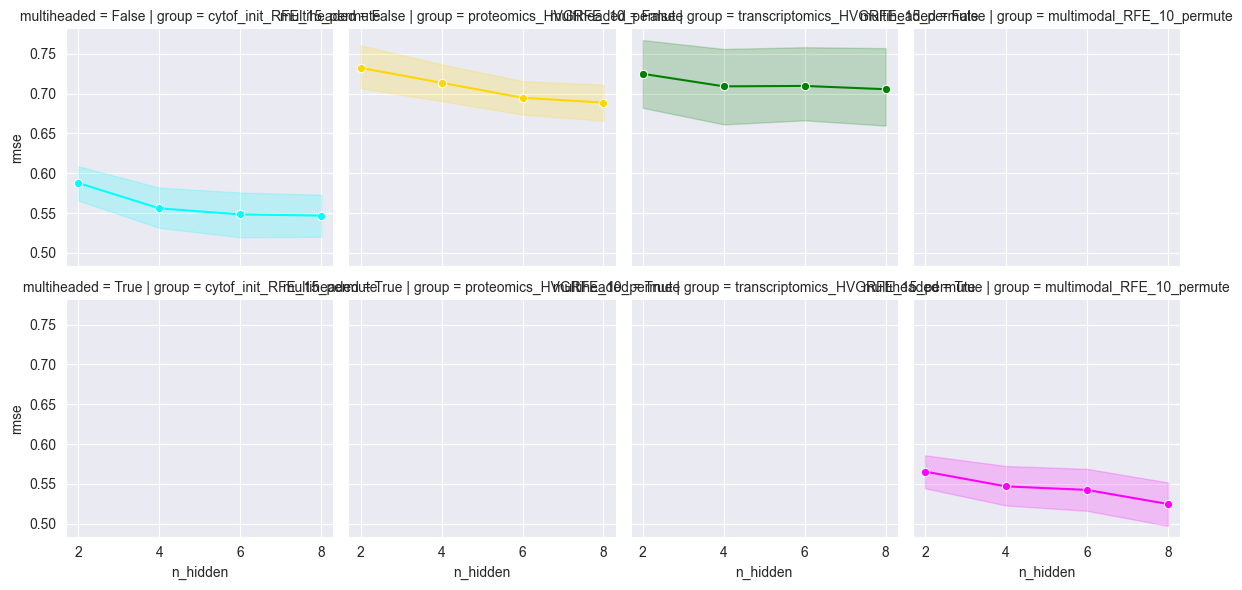

In [22]:
val_df["group"] = val_df["context"] + "_" + val_df["features"]

palette = {
    "cytof_init_RFE_15_permute": "cyan",
    "proteomics_HVGRFE_10_permute": "gold",
    "transcriptomics_HVGRFE_15_permute": "green",
    "multimodal_RFE_10_permute": "magenta",
    # "multimodal_best_RFE_10_permute": "purple"
}

g = sns.FacetGrid(
    val_df[(val_df.depth == 0) & (val_df.dropout_rate == 0.2) & (val_df.l2reg_inflater_output == 0) & (val_df.l1reg_inflater_output == 1e-2) & (val_df.recon_loss == 1e-4)],
    row="multiheaded",
    col="group",
    col_order=palette.keys()
)

g.map_dataframe(
    sns.lineplot,
    x="n_hidden",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [23]:
from scipy import stats

def kruskal_wallis_groups(df, target_metric, group_metric, context_metric="context"):
    for context in df[context_metric].unique():
        context_data = df[df[context_metric] == context]
        groups = [group[target_metric].values for _, group in context_data.groupby(group_metric)]
        stat, p_value = stats.kruskal(*groups)
        print(f"Context/Group: {context} - Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}, significant? {p_value < 0.05}")

In [24]:
kruskal_wallis_groups(
    val_df[(val_df.depth == 0) & (val_df.dropout_rate == 0.2) & (val_df.l2reg_inflater_output == 0) & (val_df.l1reg_inflater_output == 1e-2) & (val_df.recon_loss == 1e-4)],
    "rmse",
    "n_hidden",
    "group"
)

Context/Group: cytof_init_RFE_15_permute - Kruskal-Wallis H-test: H-statistic=5.23, p-value=0.1554, significant? False
Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=4.85, p-value=0.1829, significant? False
Context/Group: proteomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=6.48, p-value=0.0905, significant? False
Context/Group: transcriptomics_HVGRFE_15_permute - Kruskal-Wallis H-test: H-statistic=0.74, p-value=0.8637, significant? False


## No significant improvements, but there is a downward trend in all contexts

# `depth` (fixed n_hidden = 2)

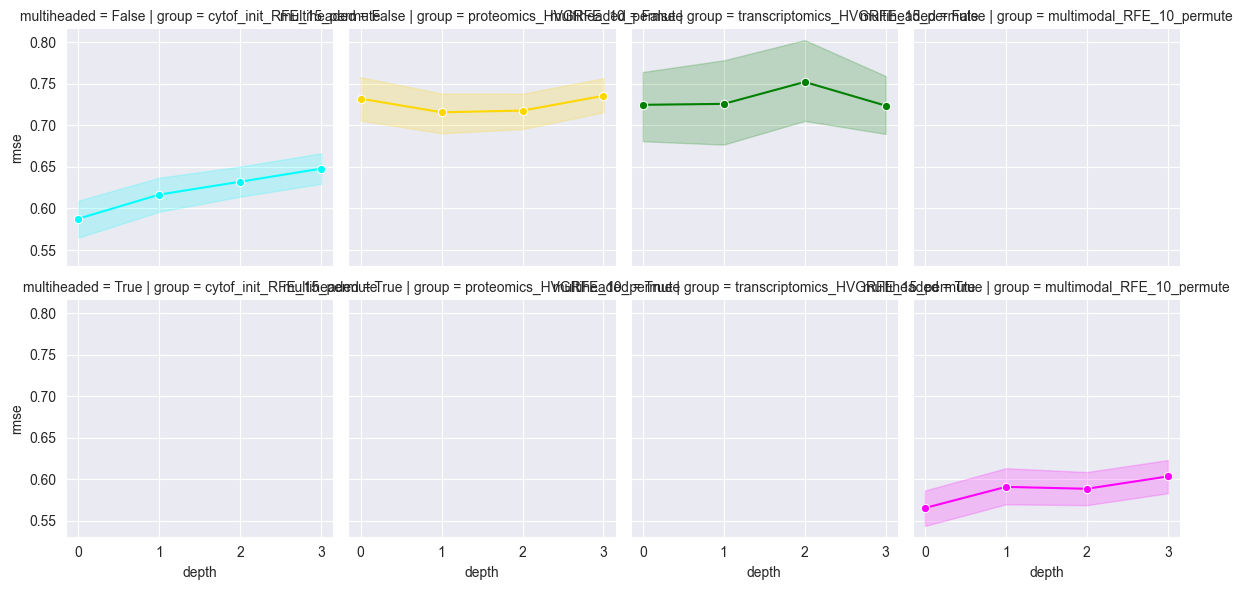

In [25]:
g = sns.FacetGrid(
    val_df[(val_df.n_hidden == 2) & (val_df.dropout_rate == 0.2) & (val_df.l2reg_inflater_output == 0) & (val_df.l1reg_inflater_output == 1e-2) & (val_df.recon_loss == 1e-4)],
    row="multiheaded",
    col="group",
    col_order=palette.keys(),
)

g.map_dataframe(
    sns.lineplot,
    x="depth",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [26]:
kruskal_wallis_groups(
    val_df[(val_df.n_hidden == 2) & (val_df.dropout_rate == 0.2) & (val_df.l2reg_inflater_output == 0) & (val_df.l1reg_inflater_output == 1e-2) & (val_df.recon_loss == 1e-4)],
    "rmse",
    "depth",
    "group"
)

Context/Group: cytof_init_RFE_15_permute - Kruskal-Wallis H-test: H-statistic=14.56, p-value=0.0022, significant? True
Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=6.91, p-value=0.0748, significant? False
Context/Group: proteomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=2.08, p-value=0.5557, significant? False
Context/Group: transcriptomics_HVGRFE_15_permute - Kruskal-Wallis H-test: H-statistic=0.47, p-value=0.9261, significant? False


# `l1reg_inflater_output` (fixed `n_hidden`, `depth` and `l2reg_inflater_output`)

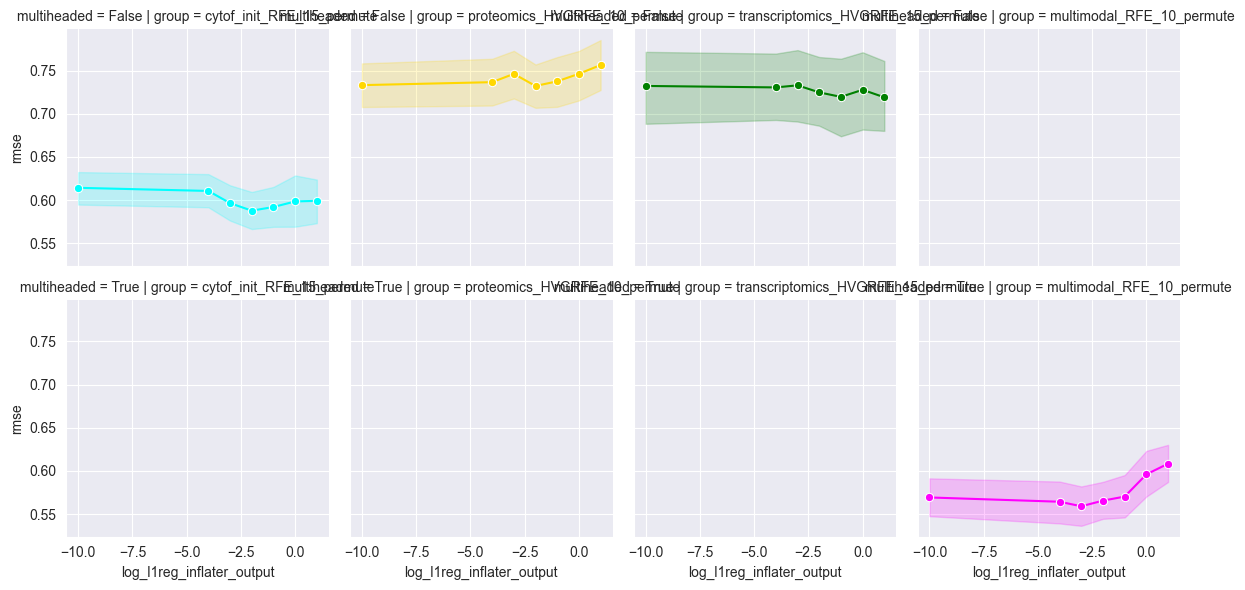

In [27]:
import numpy as np

val_df["log_l1reg_inflater_output"] = np.where(
    val_df["l1reg_inflater_output"] != 0,
    np.log10(val_df["l1reg_inflater_output"]),
    -10
)
g = sns.FacetGrid(
    val_df[(val_df.n_hidden == 2) & (val_df.dropout_rate == 0.2) & (val_df.depth == 0) & (val_df.l2reg_inflater_output == 0) & (val_df.recon_loss == 1e-4)],
    row="multiheaded",
    col="group",
    col_order=palette.keys(),
)

g.map_dataframe(
    sns.lineplot,
    x="log_l1reg_inflater_output",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [28]:
kruskal_wallis_groups(
    val_df[(val_df.n_hidden == 2) & (val_df.dropout_rate == 0.2) & (val_df.depth == 0) & (val_df.l2reg_inflater_output == 0) & (val_df.recon_loss == 1e-4)],
    "rmse",
    "log_l1reg_inflater_output",
    "group"
)

Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=15.22, p-value=0.0186, significant? True
Context/Group: proteomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=1.87, p-value=0.9312, significant? False
Context/Group: transcriptomics_HVGRFE_15_permute - Kruskal-Wallis H-test: H-statistic=0.23, p-value=0.9998, significant? False
Context/Group: cytof_init_RFE_15_permute - Kruskal-Wallis H-test: H-statistic=4.72, p-value=0.5801, significant? False


# `l2reg_inflater_output` (fixed `n_hidden`, `depth` and `l1reg_inflater_output`)

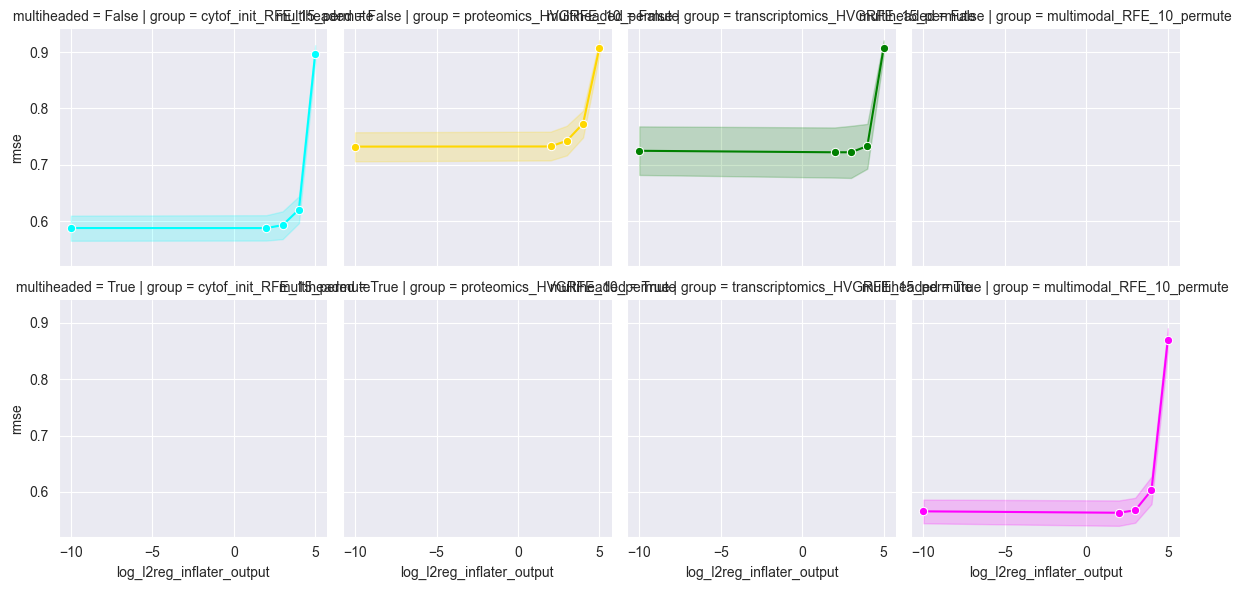

In [29]:
import numpy as np

val_df["log_l2reg_inflater_output"] = np.where(
    val_df["l2reg_inflater_output"] != 0,
    np.log10(val_df["l2reg_inflater_output"]),
    -10
)
g = sns.FacetGrid(
    val_df[(val_df.n_hidden == 2) & (val_df.dropout_rate == 0.2) & (val_df.depth == 0) & (val_df.l1reg_inflater_output == 1e-2) & (val_df.recon_loss == 1e-4)],
    row="multiheaded",
    col="group",
    col_order=palette.keys(),
)

g.map_dataframe(
    sns.lineplot,
    x="log_l2reg_inflater_output",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [30]:
kruskal_wallis_groups(
    val_df[(val_df.n_hidden == 2) & (val_df.dropout_rate == 0.2) & (val_df.depth == 0) & (val_df.l1reg_inflater_output == 1e-2) & (val_df.recon_loss == 1e-4)],
    "rmse",
    "log_l2reg_inflater_output",
    "group"
)

Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=159.86, p-value=0.0000, significant? True
Context/Group: proteomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=103.71, p-value=0.0000, significant? True
Context/Group: transcriptomics_HVGRFE_15_permute - Kruskal-Wallis H-test: H-statistic=72.57, p-value=0.0000, significant? True
Context/Group: cytof_init_RFE_15_permute - Kruskal-Wallis H-test: H-statistic=167.74, p-value=0.0000, significant? True


# Dropout Rate (`dropout_rate`)

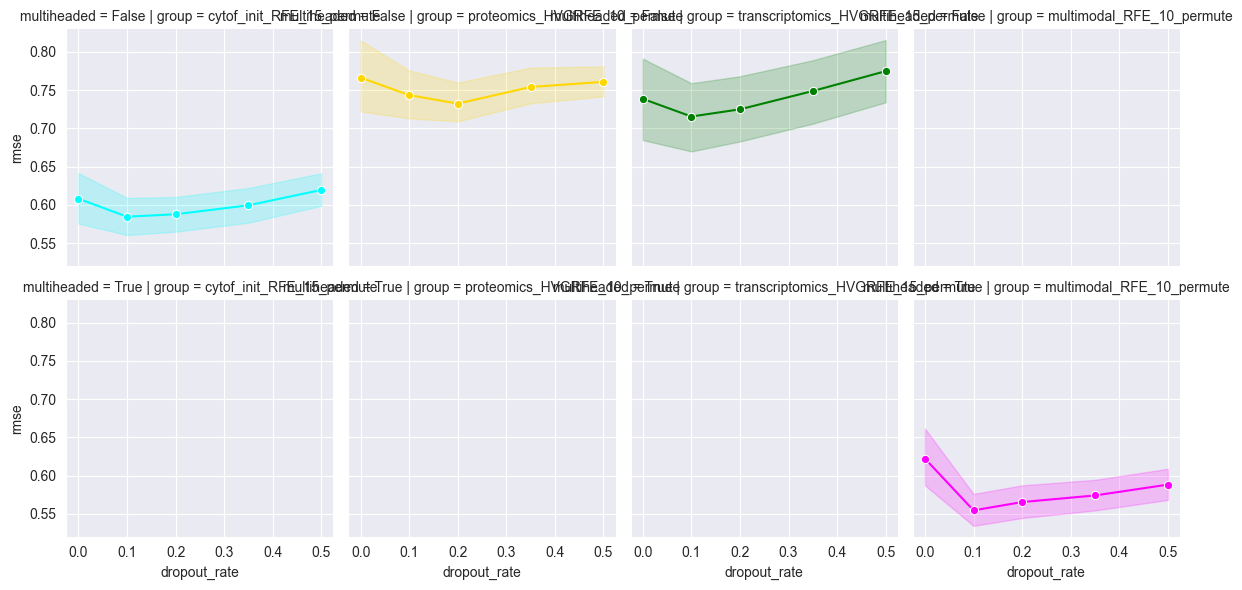

In [31]:
g = sns.FacetGrid(
    val_df[(val_df.n_hidden == 2) & (val_df.depth == 0) & (val_df.l1reg_inflater_output == 1e-2) & (val_df.l2reg_inflater_output == 0) & (val_df.recon_loss == 1e-4)],
    row="multiheaded",
    col="group",
    col_order=palette.keys(),
)

g.map_dataframe(
    sns.lineplot,
    x="dropout_rate",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [32]:
kruskal_wallis_groups(
    val_df[(val_df.n_hidden == 2) & (val_df.depth == 0) & (val_df.l1reg_inflater_output == 1e-2) & (val_df.l2reg_inflater_output == 0) & (val_df.recon_loss == 1e-4)],
    "rmse",
    "dropout_rate",
    "group"
)

Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=13.11, p-value=0.0108, significant? True
Context/Group: proteomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=3.92, p-value=0.4172, significant? False
Context/Group: transcriptomics_HVGRFE_15_permute - Kruskal-Wallis H-test: H-statistic=4.58, p-value=0.3327, significant? False
Context/Group: cytof_init_RFE_15_permute - Kruskal-Wallis H-test: H-statistic=4.35, p-value=0.3613, significant? False


# Reconstruction loss (`recon_loss`)

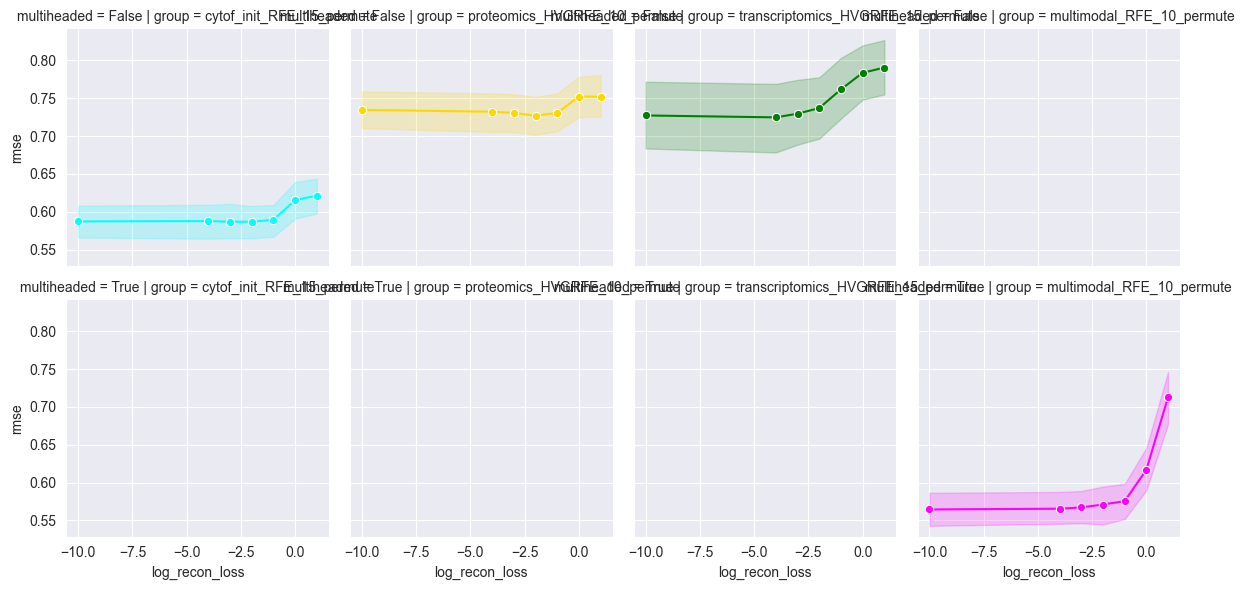

In [33]:
val_df["log_recon_loss"] = np.where(
    val_df["recon_loss"] != 0,
    np.log10(val_df["recon_loss"]),
    -10
)

g = sns.FacetGrid(
    val_df[(val_df.n_hidden == 2) & (val_df.depth == 0) & (val_df.dropout_rate == 0.2) & (val_df.l1reg_inflater_output == 1e-2) & (val_df.l2reg_inflater_output == 0)],
    row="multiheaded",
    col="group",
    col_order=palette.keys(),
)

g.map_dataframe(
    sns.lineplot,
    x="log_recon_loss",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [39]:
val_df.groupby(
    ["context", "n_hidden", "depth", "l1reg_inflater_output", "l2reg_inflater_output", "dropout_rate", "recon_loss"]
).rmse.mean()

context          n_hidden  depth  l1reg_inflater_output  l2reg_inflater_output  dropout_rate  recon_loss
cytof_init       2.0       0.0    0.0000                 0.0                    0.2           0.0001        0.614198
                                  0.0001                 0.0                    0.2           0.0001        0.610579
                                  0.0010                 0.0                    0.2           0.0001        0.596449
                                  0.0100                 0.0                    0.0           0.0001        0.608058
                                                                                0.1           0.0001        0.584546
                                                                                                              ...   
transcriptomics  2.0       2.0    0.0100                 0.0                    0.2           0.0001        0.752283
                           3.0    0.0100                 0.0                